In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

import Functions

In [14]:
df_stats = pd.read_csv('/home/frank/Desktop/f.chiapperino_local/VALENCIA/SCUOLA/App/Documents/csv/TimeSeries_Coherencia.csv', index_col='Code')
df_stats['Date'] = pd.to_datetime(df_stats['Date'])
display(df_stats)

,Date_Band,mean,std,Date,Band,Name,Type
Code,,,,,,,
1841224,20170104_VH,0.846021,0.060364,2017-01-04,VH,DB_A_C,Potatoes
1841225,20170104_VH,0.840426,0.040722,2017-01-04,VH,DB_SB1_C,Beets
1841225,20170104_VV,0.897662,0.030638,2017-01-04,VV,DB_SB1_C,Beets
1545384,20170104_VH,0.835465,0.060918,2017-01-04,VH,DB_SB2_C,Potatoes
1697691,20170104_VH,0.000000,0.000000,2017-01-04,VH,PE_A3_C,Potatoes
...,...,...,...,...,...,...,...
1697689,20171224_VH,0.892655,0.041816,2017-12-24,VH,SB7_ER_C,Grassland
1697689,20171224_VV,0.949890,0.022237,2017-12-24,VV,SB7_ER_C,Grassland
1553694,20171224_VV,0.930482,0.054510,2017-12-24,VV,DB_SB2_C,Beets


In [15]:
df_stats.drop(df_stats[df_stats['mean'] == 0].index,inplace=True)
date_S1 = list(pd.unique(pd.to_datetime(df_stats['Date'])))
#print(df_stats)

In [16]:
df_height = pd.read_csv(r'/home/frank/Desktop/f.chiapperino_local/VALENCIA/SCUOLA/App/Documents/csv/Averaged_crop_height.csv', header=0)
df_height = df_height.set_index(df_height['Code'])
df_height = df_height.drop(columns=['Code'])

date_height = list(pd.to_datetime(df_height.columns))
#display(date_height)

Create dataframe for merging

In [17]:
df_date_height = pd.DataFrame({'original_date': date_height}).sort_values('original_date')
df_date_S1 = pd.DataFrame({'ref_date': date_S1}).sort_values('ref_date')

new_date_height = pd.merge_asof(df_date_height, df_date_S1, 
                                left_on='original_date',
                                right_on='ref_date', direction='backward')

#ref_date is the one we need
display(new_date_height)

,original_date,ref_date
0,2017-05-18,2017-05-16
1,2017-05-23,2017-05-22
2,2017-05-30,2017-05-28
3,2017-06-08,2017-06-03
4,2017-06-15,2017-06-09
5,2017-06-21,2017-06-09
6,2017-06-27,2017-06-27
7,2017-07-03,2017-07-03
8,2017-07-06,2017-07-03
9,2017-07-13,2017-07-09


In [18]:
df_height.columns = new_date_height['ref_date']
#display(df_height)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

polarizzazioni = ['VV', 'VH']

tabella_risultati = []
for codice in np.unique(df_stats.index):
    for pol in polarizzazioni:
        
        if codice not in df_height.index:
            continue
        df_growth = df_height.loc[codice].dropna()
        df_growth.index = pd.to_datetime(df_growth.index)
        df_growth = df_growth.groupby(level=0).mean()
        
        if codice not in df_stats.index:
            continue

        df_S1 = df_stats.loc[codice].dropna()
        df_S1_pol = df_S1[df_S1['Band'] == pol].copy()
        
        if df_S1_pol.empty:
            continue
            
        df_S1_pol.set_index(pd.to_datetime(df_S1_pol['Date']), inplace=True)
        
        df_reg = pd.merge(df_growth, df_S1_pol[['mean', 'Type']], 
                          left_index=True, right_index=True, how='inner')
        
        if len(df_reg) < 3:
            continue

        '''
        col_growth = df_reg.columns[0] 
        x = df_reg['mean'].diff().dropna()
        y = df_reg[col_growth].diff().dropna()
        '''

        col_growth = df_reg.columns[0] 
        x = df_reg['mean'].dropna()
        y = df_reg[col_growth].dropna()

        # Allineamento dopo il diff()
        df_diff = pd.concat([x, y], axis=1).dropna()
        
        # 4. Regressione Lineare
        slope, intercept, r_value, p_value, std_err = stats.linregress(df_diff.iloc[:,0], df_diff.iloc[:,1])
        

        # 5. Aggiunta alla lista
        tabella_risultati.append({
            'Code': codice,
            'Type': df_reg['Type'].iloc[0],
            'Pol': pol,
            'R2': r_value**2,
            'P_value': p_value,
            'Slope': slope,
            'Intercept': intercept,
            'N_points': len(df_diff)
        })

display(df_diff)
df_final_results = pd.DataFrame(tabella_risultati)

display(df_final_results.sort_values('R2',ascending=False))


,mean,2278835.0
ref_date,,
2017-06-09,0.201376,95.50
2017-06-27,0.146306,130.00
2017-07-03,0.209977,173.50
2017-07-09,0.196907,235.00
2017-07-15,0.179240,270.00
2017-07-21,0.201117,296.75
2017-08-08,0.231853,290.00
2017-08-14,0.232278,297.50
2017-08-20,0.249999,292.50


,Code,Type,Pol,R2,P_value,Slope,Intercept,N_points
14,1698168,Corn,VV,0.974755,0.101581,-891.193048,442.529916,3
10,1697689,Grassland,VV,0.923468,0.009201,-145.239881,52.450071,5
30,2041694,Potatoes,VV,0.749478,0.057861,-643.044632,195.818094,5
36,2081887,Corn,VV,0.724514,0.003608,-1955.712114,654.838357,9
0,1545384,Potatoes,VV,0.698693,0.001350,-87.188612,88.508049,11
13,1697690,Grassland,VH,0.696135,0.078893,-179.160209,62.339482,5
18,1841223,Wheat,VV,0.689248,0.000443,-189.607168,114.691374,13
12,1697690,Grassland,VV,0.682997,0.084504,-142.137586,56.125000,5
1,1545384,Potatoes,VH,0.652393,0.002637,-117.297500,93.584798,11
22,1896343,Corn,VV,0.644204,0.002943,3890.971614,-525.475489,11


In [ ]:
df_final_results.to_csv('/home/frank/Desktop/f.chiapperino_local/VALENCIA/SCUOLA/App/Documents/csv/Regression.csv', index=False)

Preparing the dataframes for the regression

In [21]:
code = 1631664
# Filtra i dati per la parcella 1553694
df_S1_beets = df_stats.loc[code].dropna()
df_S1_beets_VV = df_S1_beets[df_S1_beets['Band'] == 'VH']
df_S1_beets_VV.set_index(df_S1_beets_VV['Date'], inplace=True)

df_growth_beets = df_height.loc[code].dropna()
df_growth_beets.index = pd.to_datetime(df_growth_beets.index)
df_growth_beets = df_growth_beets.groupby(level=0).mean()



df_regression = pd.merge(df_growth_beets, df_S1_beets_VV['mean'], 
                         left_index=True, right_index=True, how='inner')


display(df_regression)
df_regression[code] = df_regression[code].diff()

df_regression['mean'] = df_regression['mean'].diff()
#display(df_S1_beets_VV['mean'])


#print(df_S1_beets['Date'])


#print(df_S1_beets.index)

#display(df_regression)

,1631664.0,mean
ref_date,,
2017-05-16,21.00,0.416857
2017-05-22,23.00,0.388828
2017-05-28,38.00,0.345951
2017-06-09,11.50,0.182828
2017-06-27,20.00,0.267640
2017-07-03,20.50,0.255662
2017-07-09,31.00,0.238156
2017-07-15,37.75,0.176891
2017-07-21,24.00,0.191918


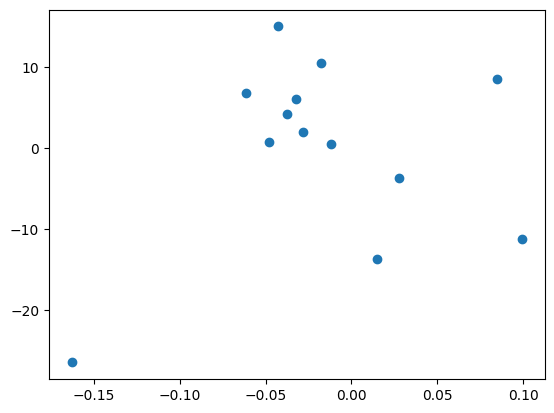

In [22]:
plt.scatter(df_regression['mean'],df_regression[code])

regressione

Coefficiente di correlazione (R): 0.211
P-value: 4.8906e-01


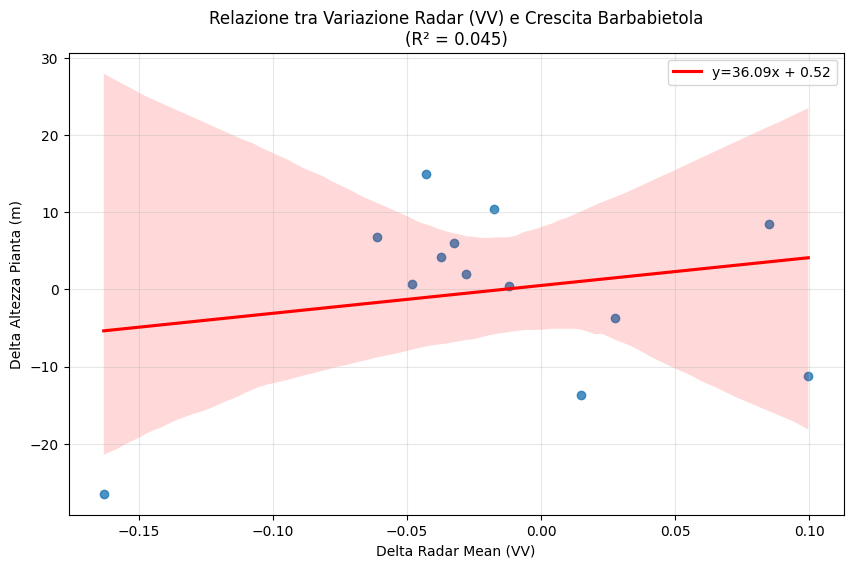

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Rimuoviamo i valori NaN creati dal comando .diff()
df_regression_clean = df_regression.dropna()

# 2. Calcoliamo la regressione lineare
# X = variazione segnale satellitare (mean), y = variazione altezza (1553694.0)
x = df_regression_clean['mean']
y = df_regression_clean[code]

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

print(f"Coefficiente di correlazione (R): {r_value:.3f}")
print(f"P-value: {p_value:.4e}") # Se < 0.05, la relazione è statisticamente significativa

# 3. Visualizzazione
plt.figure(figsize=(10, 6))
sns.regplot(x=x, y=y, ci=95, line_kws={'color':'red', 'label': f'y={slope:.2f}x + {intercept:.2f}'})

plt.title(f'Relazione tra Variazione Radar (VV) e Crescita Barbabietola\n(R² = {r_value**2:.3f})')
plt.xlabel('Delta Radar Mean (VV)')
plt.ylabel('Delta Altezza Pianta (m)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()